<a href="https://colab.research.google.com/github/Luseat/KlasifikasiRnadomForest/blob/main/pembuatan_model_random_forest_%26_bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_Skripsi_RF_Final.xlsx to Dataset_Skripsi_RF_Final.xlsx


In [3]:
import pandas as pd

# Membaca dataset Excel
df = pd.read_excel('Dataset_Skripsi_RF_Final.xlsx')
df.head(25)

,usia,jenis_kelamin,status,omset,jumlah_pinjaman,tenor_pinjaman_(bulan),jumlah_anak,riwayat_telat_bayar,status_pinjaman
0,29,laki-laki,wirausaha,20000000,30000000,36,2,0,Approved
1,30,Perempuan,Wirausaha,15000000,100000000,36,0,0,Approved
2,27,Perempuan,Karyawan,148800000000,463450000000,144,2,0,Approved
3,40,Perempuan,Wirausaha,63550000000,189100000000,96,0,1,Rejected
4,49,Perempuan,Karyawan,141050000000,460350000000,240,3,1,Rejected
5,35,Perempuan,Karyawan,127100000000,475850000000,96,3,1,Rejected
6,31,Perempuan,Wirausaha,151900000000,375100000000,240,5,0,Rejected
7,28,Laki-laki,Wirausaha,74400000000,209250000000,120,0,0,Rejected
8,49,Laki-laki,Karyawan,134850000000,511500000000,48,5,0,Approved
9,41,Laki-laki,Wirausaha,88350000000,232500000000,240,2,1,Rejected


**Preprocessing**

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 1 Load Data sesuaikan pemisahnya pakai titik koma ';'
df = pd.read_excel("Dataset_Skripsi_RF_Final.xlsx")


# Ubah menjadi huruf kecil semua
df['jenis_kelamin'] = df['jenis_kelamin'].str.lower()
df['status'] = df['status'].str.lower()

In [5]:
# 2 Ubah Target jadi Angka sesuai Flowchart: 0 = Approved, 1 = Reject(ed)
df['status_pinjaman'] = df['status_pinjaman'].map({'Approved': 0, 'Rejected': 1})


# Pisahin fitur (X) dan target (y)
X = df.drop('status_pinjaman', axis=1)
y = df['status_pinjaman']

In [6]:
# 3 Setting Preprocessing (Sesuai Metodologi Sistem)
numeric_features = ['usia', 'omset', 'jumlah_pinjaman', 'tenor_pinjaman_(bulan)', 'jumlah_anak', 'riwayat_telat_bayar']
categorical_features = ['jenis_kelamin', 'status']


# Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), #Handling Missing Value
    ('scaler', StandardScaler()) #Standarisasi scala seimbang
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))# encoding -> kategory
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [7]:
df.head(15)

,usia,jenis_kelamin,status,omset,jumlah_pinjaman,tenor_pinjaman_(bulan),jumlah_anak,riwayat_telat_bayar,status_pinjaman
0,29,laki-laki,wirausaha,20000000,30000000,36,2,0,0
1,30,perempuan,wirausaha,15000000,100000000,36,0,0,0
2,27,perempuan,karyawan,148800000000,463450000000,144,2,0,0
3,40,perempuan,wirausaha,63550000000,189100000000,96,0,1,1
4,49,perempuan,karyawan,141050000000,460350000000,240,3,1,1
5,35,perempuan,karyawan,127100000000,475850000000,96,3,1,1
6,31,perempuan,wirausaha,151900000000,375100000000,240,5,0,1
7,28,laki-laki,wirausaha,74400000000,209250000000,120,0,0,1
8,49,laki-laki,karyawan,134850000000,511500000000,48,5,0,0
9,41,laki-laki,wirausaha,88350000000,232500000000,240,2,1,1


**Split Data Training dan Testing (80:20)**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Data berhasil di-load dan siapa diproses...")
print(f"Jumlah data training: {X_train.shape[0]}, Jumlah data testing: {X_test.shape[0]}")



Data berhasil di-load dan siapa diproses...
Jumlah data training: 3416, Jumlah data testing: 855


**Model Random Forest**

In [9]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

**Model Bagging Pakai Decision Tree sebagai base modelnya**

In [10]:
bagging_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

**Model Voting (Mekanisme Majority Voting / Hard Voting suara terbanyak)**

Hard voting → setiap model memberi prediksi kelas, lalu hasil akhir ditentukan dengan mayoritas suara.

Soft voting → setiap model memberi probabilitas prediksi, lalu probabilitas digabungkan dan dipilih kelas dengan skor tertinggi.

In [11]:
Voting_classifier = VotingClassifier(
    estimators=[
        ('Random Forest', rf_classifier),
        ('Bagging', bagging_classifier)
    ],
    voting='hard' # 'hard' voting untuk majority rule
)

**Bikin pipeline utuh dari Preprocessing sampai Model untuk ketiga sistem**

In [12]:
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_classifier)])
pipeline_bagging = Pipeline(steps=[('preprocessor', preprocessor), ('model', bagging_classifier)])
pipeline_voting = Pipeline(steps=[('preprocessor', preprocessor), ('model', Voting_classifier)])

**Latih semua model (Training)**

In [13]:
pipeline_rf.fit(X_train, y_train)
pipeline_bagging.fit(X_train, y_train)
pipeline_voting.fit(X_train, y_train)

print("Semua model selesai dilatih...")

Semua model selesai dilatih...


**Fungsi untuk nge-test dan cetak hasil akurasi**

In [14]:
def evaluasi_model(nama_model, pipeline, X_test_data, y_test_data):
    y_pred = pipeline.predict(X_test_data)
    akurasi = accuracy_score(y_test_data, y_pred)
    print(f"=== Kinerja Model: {nama_model} ===")
    print(f"Akurasi: {akurasi * 100:.2f}%")
    print("Confusion Matrix:\n", confusion_matrix(y_test_data, y_pred))
    print("Classification Report:\n", classification_report(y_test_data, y_pred))
    print("-" * 50)

**Cek kinerja masing-masing model**

In [15]:
evaluasi_model("Random Forest", pipeline_rf, X_test, y_test)
evaluasi_model("Bagging", pipeline_bagging, X_test, y_test)
evaluasi_model("Voting Classifier (Hasil Akhir)", pipeline_voting, X_test, y_test)

=== Kinerja Model: Random Forest ===
Akurasi: 77.78%
Confusion Matrix:
 [[467  62]
 [128 198]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83       529
           1       0.76      0.61      0.68       326

    accuracy                           0.78       855
   macro avg       0.77      0.75      0.75       855
weighted avg       0.78      0.78      0.77       855

--------------------------------------------------
=== Kinerja Model: Bagging ===
Akurasi: 76.73%
Confusion Matrix:
 [[460  69]
 [130 196]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       529
           1       0.74      0.60      0.66       326

    accuracy                           0.77       855
   macro avg       0.76      0.74      0.74       855
weighted avg       0.76      0.77      0.76       855

--------------------------------------------------
=== Kinerja 

77% buat kasus prediksi risiko kredit (Credit Scoring) di dunia nyata itu sangat realistis dan wajar. Kalau untuk penelitian angka segini jauh lebih bisa dipercaya dan gampang dipertanggungjawabkan pas sidang, daripada tiba-tiba mendapatkan akurasi 98% yang biasanya dapat dicurigai overfitting atau datanya bocor.

**Mengapa Demikian begitu?**

Akurasi 77%: Artinya dari semua tebakan modelnya 77% tebakannya udah bener. Buat data finansial/manusia yang perilakunya susah ditebak, ini angka yang solid sebagai baseline penelitian.
Hasil antar model stabil: Random Forest (77.78%), Bagging (76.73%), dan Voting (77.66%) hasilnya mirip-mirip. Artinya model ini cukup stabil dan nggak ngawur.

# **Poin Plus pada hasil dalam penelitian ini : mengenai soal metrik Recall di Class 1 (Reject)**


Perhatiin di Classification Report, bagian recall untuk label 1 (Reject) angkanya sekitar 0.59 - 0.61 (59% - 61%).
**Artinya secara bisnis:** Dari 100 calon debitur yang aslinya bakal gagal bayar (berisiko), model ini berhasil nangkap/nge-reject 61 orang, tapi 39 orang sisanya lolos (dikira aman).

Sebaliknya, recall buat label 0 (Approved) tinggi banget ~0.88 (88%). Artinya model lu jago banget ngenalin orang yang emang bayarnya lancar.

**Visualisasi Confusion Matrix Heatmap**

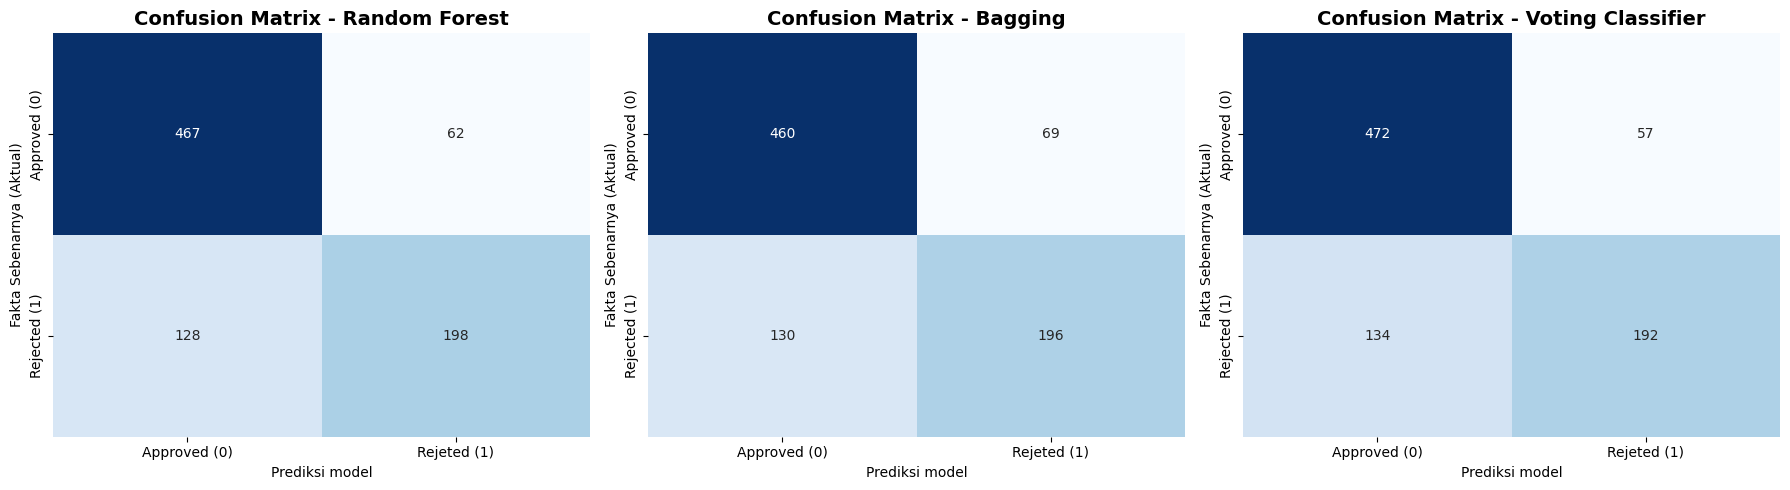

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


# Canvas buat 3 gambar sejajar
fig, axs = plt.subplots(1, 3, figsize=(18,5))
models = [
    ("Random Forest", pipeline_rf),
    ("Bagging", pipeline_bagging),
    ("Voting Classifier", pipeline_voting)
]


for i, (nama, model) in enumerate(models):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)


  #Bikin Headmap
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i], cbar=False,
              xticklabels=['Approved (0)', 'Rejeted (1)'],
              yticklabels=['Approved (0)', 'Rejected (1)'])
  axs[i].set_title(f'Confusion Matrix - {nama}', fontsize=14, fontweight='bold')
  axs[i].set_xlabel('Prediksi model')
  axs[i].set_ylabel('Fakta Sebenarnya (Aktual)')


plt.tight_layout()
plt.show()